In [50]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [51]:
iris = load_iris()

In [52]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [53]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [54]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [55]:
X = df.drop('target', axis='columns')
y = df.target

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [57]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [58]:
model.score(X_train, y_train)

1.0

In [59]:
model.score(X_test, y_test)

0.9333333333333333

In [60]:
scores = []

for n in [5,10,20,50,100,200]:

    model = RandomForestClassifier(n_estimators=n)

    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)

    scores.append((n, score))

scores

[(5, 1.0),
 (10, 0.9333333333333333),
 (20, 0.9333333333333333),
 (50, 0.9666666666666667),
 (100, 0.9333333333333333),
 (200, 0.9666666666666667)]

In [61]:
for n, score in scores:
    print("Trees:", n, " Score:", score)

Trees: 5  Score: 1.0
Trees: 10  Score: 0.9333333333333333
Trees: 20  Score: 0.9333333333333333
Trees: 50  Score: 0.9666666666666667
Trees: 100  Score: 0.9333333333333333
Trees: 200  Score: 0.9666666666666667


Text(58.222222222222214, 0.5, 'Truth')

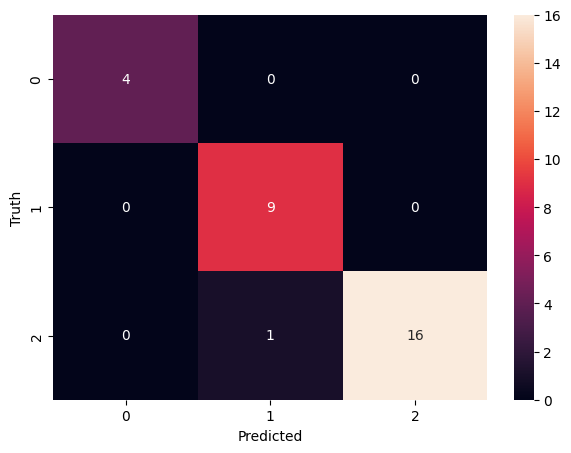

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

y_predicted = model.predict(X_test)

cm = confusion_matrix(y_test, y_predicted)

plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True)

plt.xlabel('Predicted')
plt.ylabel('Truth')